## Baseline: Logistic Regression

In [1]:
import os
os.chdir('..')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import RandomizedSearchCV

from catboost import CatBoostClassifier
import shap

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('data/processed/credit_data_final.csv')

In [3]:
df.head(7)

,creditability,account_balance,duration_of_credit_monthly,payment_status_of_previous_credit,purpose,credit_amount,value_savings_stocks,length_of_current_employment,instalment_per_cent,sex_marital_status,...,duration_in_current_address,most_valuable_available_asset,age_years,concurrent_credits,type_of_apartment,no_of_credits_at_this_bank,occupation,no_of_dependents,telephone,credit_amount_per_month
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,58.277778
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,311.000000
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,70.083333
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,176.833333
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,180.916667
5,1,1,10,4,0,2241,1,2,1,3,...,3,1,48,3,1,2,2,2,1,224.100000
6,1,1,8,4,0,3398,1,4,1,3,...,4,1,39,3,2,2,2,1,1,424.750000


In [4]:
target_col = 'creditability'

numeric_cols = ['duration_of_credit_monthly', 'credit_amount', 'age_years', 'credit_amount_per_month']

cat_cols = [c for c in df.columns if c not in numeric_cols + [target_col]]

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

In [5]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(np.unique(y_pred, return_counts=True))

              precision    recall  f1-score   support

           0       0.55      0.78      0.65        60
           1       0.89      0.73      0.80       140

    accuracy                           0.74       200
   macro avg       0.72      0.76      0.72       200
weighted avg       0.79      0.74      0.75       200

ROC-AUC: 0.8336
(array([0, 1]), array([ 85, 115]))


### Baseline Metrics Visualization

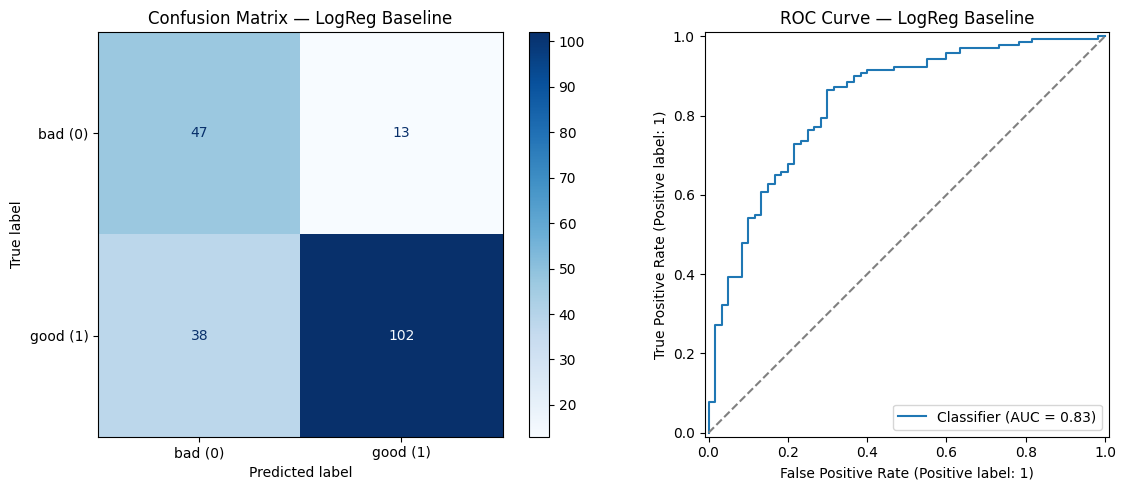

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['bad (0)', 'good (1)'], ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix — LogReg Baseline')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve — LogReg Baseline')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')  # диагональ рандома

plt.tight_layout()
plt.show()

## Catboost

In [7]:
cat_features_idx = [X_train.columns.get_loc(c) for c in cat_cols]

catboost_baseline = CatBoostClassifier(
    random_state=42,
    verbose=False
)

catboost_baseline.fit(X_train, y_train, cat_features=cat_features_idx)

y_pred_cb = catboost_baseline.predict(X_test)
y_proba_cb = catboost_baseline.predict_proba(X_test)[:, 1]

In [8]:
print(classification_report(y_test, y_pred_cb, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_cb):.4f}")

              precision    recall  f1-score   support

           0       0.67      0.43      0.53        60
           1       0.79      0.91      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.67      0.68       200
weighted avg       0.75      0.77      0.75       200

ROC-AUC: 0.8324


### CatBoost with Balanced Class Weights

In [9]:
catboost_balanced = CatBoostClassifier(
    random_state=42,
    verbose=False,
    auto_class_weights='Balanced'
)

catboost_balanced.fit(X_train, y_train, cat_features=cat_features_idx)

y_pred_cb_bal = catboost_balanced.predict(X_test)
y_proba_cb_bal = catboost_balanced.predict_proba(X_test)[:, 1]

In [10]:
print(classification_report(y_test, y_pred_cb_bal, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_cb_bal):.4f}")

              precision    recall  f1-score   support

           0       0.62      0.67      0.64        60
           1       0.85      0.82      0.84       140

    accuracy                           0.78       200
   macro avg       0.73      0.74      0.74       200
weighted avg       0.78      0.78      0.78       200

ROC-AUC: 0.8285


### CatBoost Hyperparameter Tuning

In [11]:

param_grid = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'iterations': [200, 500, 1000]
}

cb = CatBoostClassifier(
    random_state=42,
    verbose=False,
    auto_class_weights='Balanced'
)

search = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train, cat_features=cat_features_idx)

RandomizedSearchCV(cv=5,
                   estimator=<catboost.core.CatBoostClassifier object at 0x178dc8e60>,
                   n_iter=30, n_jobs=-1,
                   param_distributions={'depth': [4, 6, 8, 10],
                                        'iterations': [200, 500, 1000],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1]},
                   random_state=42, scoring='roc_auc')

In [12]:
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

Best params: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 4}
Best CV ROC-AUC: 0.7870535714285714


In [13]:
best_cb = search.best_estimator_

y_pred_tuned = best_cb.predict(X_test) # type: ignore
y_proba_tuned = best_cb.predict_proba(X_test)[:, 1] # type: ignore

print(classification_report(y_test, y_pred_tuned, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}")

              precision    recall  f1-score   support

           0       0.62      0.67      0.65        60
           1       0.85      0.83      0.84       140

    accuracy                           0.78       200
   macro avg       0.74      0.75      0.74       200
weighted avg       0.78      0.78      0.78       200

ROC-AUC: 0.8335


### SHAP Analysis

In [14]:
explainer = shap.TreeExplainer(best_cb)
shap_values = explainer.shap_values(X_test)

#### Numeric: Mean |SHAP value| per feature

In [15]:
mean_abs_shap = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(mean_abs_shap.to_string(index=False))

                          feature  mean_abs_shap
                  account_balance       0.605865
             value_savings_stocks       0.301679
       duration_of_credit_monthly       0.287966
          credit_amount_per_month       0.223556
                          purpose       0.223060
                    credit_amount       0.217479
payment_status_of_previous_credit       0.201655
                        age_years       0.107858
               sex_marital_status       0.102948
      duration_in_current_address       0.078851
                type_of_apartment       0.075925
               concurrent_credits       0.073774
                       guarantors       0.073260
     length_of_current_employment       0.068445
              instalment_per_cent       0.066370
    most_valuable_available_asset       0.065350
                        telephone       0.061934
                       occupation       0.044692
       no_of_credits_at_this_bank       0.026235
                 no_

#### Graphical: SHAP Summary Plot

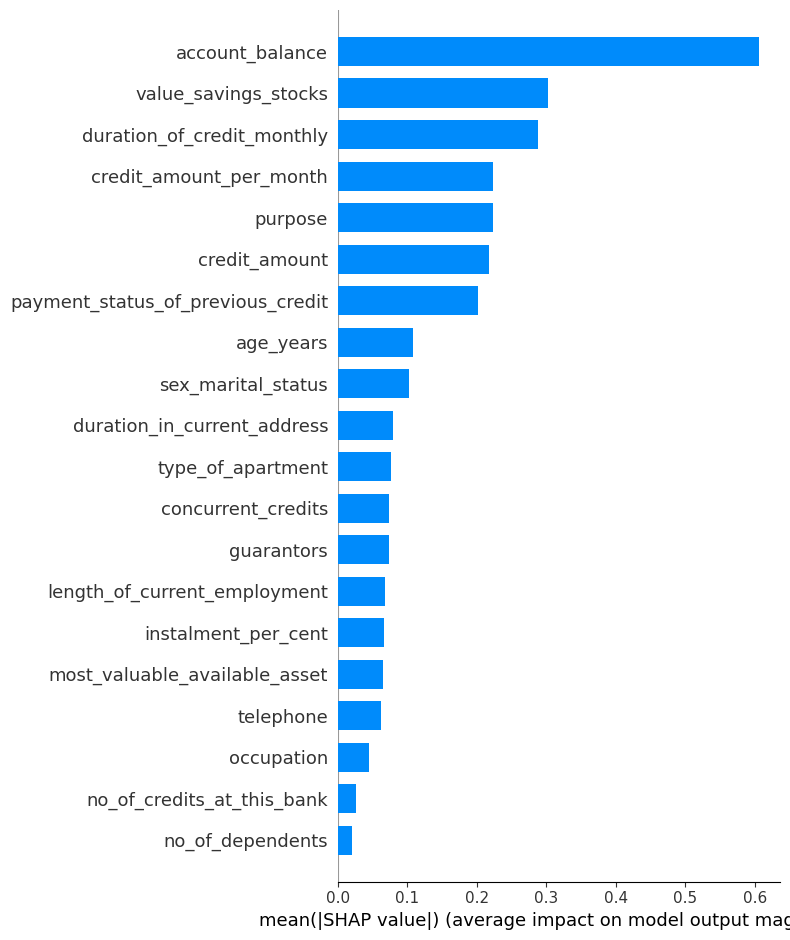

In [16]:
shap.summary_plot(shap_values, X_test, plot_type='bar')

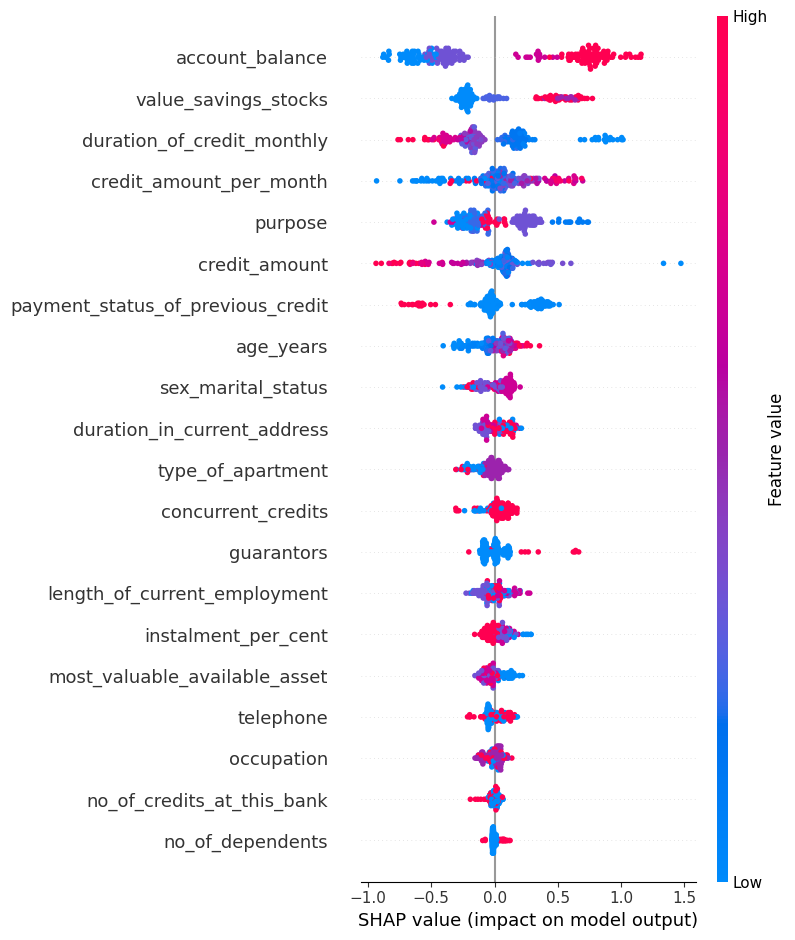

In [17]:
shap.summary_plot(shap_values, X_test)

### CatBoost without weak features

In [18]:
weak_features = ['telephone', 'no_of_dependents', 'no_of_credits_at_this_bank',
                  'occupation', 'most_valuable_available_asset', 'instalment_per_cent']

X_train_reduced = X_train.drop(columns=weak_features)
X_test_reduced = X_test.drop(columns=weak_features)

cat_cols_reduced = [c for c in cat_cols if c not in weak_features]
cat_features_idx_reduced = [X_train_reduced.columns.get_loc(c) for c in cat_cols_reduced]

cb_reduced = CatBoostClassifier(
    learning_rate=0.05,
    l2_leaf_reg=5,
    iterations=500,
    depth=4,
    random_state=42,
    verbose=False,
    auto_class_weights='Balanced'
)

cb_reduced.fit(X_train_reduced, y_train, cat_features=cat_features_idx_reduced)

y_pred_reduced = cb_reduced.predict(X_test_reduced)
y_proba_reduced = cb_reduced.predict_proba(X_test_reduced)[:, 1]

In [19]:
print(classification_report(y_test, y_pred_reduced, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_reduced):.4f}")

              precision    recall  f1-score   support

           0       0.62      0.63      0.63        60
           1       0.84      0.84      0.84       140

    accuracy                           0.78       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.78      0.78      0.78       200

ROC-AUC: 0.8282


###  New features

In [22]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe['balance_savings_combo'] = X_train_fe['account_balance'].astype(str) + '_' + X_train_fe['value_savings_stocks'].astype(str)
X_test_fe['balance_savings_combo'] = X_test_fe['account_balance'].astype(str) + '_' + X_test_fe['value_savings_stocks'].astype(str)

cat_cols_fe = cat_cols + ['balance_savings_combo']
cat_features_idx_fe = [X_train_fe.columns.get_loc(c) for c in cat_cols_fe]

In [23]:
cb_fe = CatBoostClassifier(
    learning_rate=0.05,
    l2_leaf_reg=5,
    iterations=500,
    depth=4,
    random_state=42,
    verbose=False,
    auto_class_weights='Balanced'
)

cb_fe.fit(X_train_fe, y_train, cat_features=cat_features_idx_fe)

y_pred_fe = cb_fe.predict(X_test_fe)
y_proba_fe = cb_fe.predict_proba(X_test_fe)[:, 1]

In [24]:
print(classification_report(y_test, y_pred_fe, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_fe):.4f}")

              precision    recall  f1-score   support

           0       0.61      0.65      0.63        60
           1       0.85      0.82      0.83       140

    accuracy                           0.77       200
   macro avg       0.73      0.74      0.73       200
weighted avg       0.77      0.77      0.77       200

ROC-AUC: 0.8299


## Заключение по этапу моделирования

Задача: предсказать кредитоспособность клиента (German Credit Data), с упором на recall для класса "bad" — банку дороже одобрить плохой кредит, чем отказать хорошему.

**Сравнение моделей:**

| Модель | Recall (bad) | Precision (bad) | ROC-AUC |
|---|---|---|---|
| LogReg (baseline, balanced) | 0.77 | 0.54 | 0.8294 |
| CatBoost (default) | 0.43 | 0.67 | 0.8324 |
| CatBoost (balanced weights) | 0.67 | 0.62 | 0.8285 |
| CatBoost (tuned) | 0.67 | 0.62 | 0.8335 |
| CatBoost (без слабых фич) | 0.63 | 0.62 | 0.8282 |
| CatBoost (+ интеракция account_balance×value_savings_stocks) | 0.65 | 0.62 | 0.8299 |

**Выводы:**
- Дефолтный CatBoost без балансировки классов сильно недооценивает bad-класс (recall 0.43) — балансировка весов (`auto_class_weights='Balanced'`) обязательна при таком дисбалансе (700/300).
- Тюнинг гиперпараметров через RandomizedSearchCV дал минимальный прирост — данных (~800 строк train) слишком мало, чтобы гиперпараметры сильно на что-то влияли.
- SHAP показал явных лидеров:

## Сохранение финальной модели

In [26]:
os.makedirs('models', exist_ok=True)
best_cb.save_model('models/credit_scoring_catboost.cbm') # type: ignore